# Autoencoder Anomaly Detection — Hyperparameter Comparison

This notebook follows the same workflow as `autoencoder.ipynb` but trains the model across **6 hyperparameter combinations** to compare their performance.

**Combinations tested:**

| # | Architecture (encoder) | Latent Dim | Description |
|---|---|---|---|
| 1 | 535 → 256 → 128 | 16 | Shallow, very compressed |
| 2 | 535 → 256 → 128 | 32 | Shallow, moderate compression |
| 3 | 535 → 256 → 128 | 64 | Shallow, less compressed |
| 4 | 535 → 512 → 256 → 128 | 16 | Deep, very compressed |
| 5 | 535 → 512 → 256 → 128 | 32 | Deep, moderate compression |
| 6 | 535 → 512 → 256 → 128 | 64 | Deep, less compressed |

**What we are varying:**
- **Architecture depth** — shallow (2 hidden layers) vs deep (3 hidden layers). A deeper model can learn more complex spectral patterns but risks over-fitting to normal data.
- **Latent dimension** — controls how aggressively the input is compressed. A smaller bottleneck forces the model to discard fine details, which can improve anomaly detection: the model learns only the most common spectral patterns and reconstructs anomalies poorly.

**Fixed across all runs:** `LEARNING_RATE=1e-3`, `EPOCHS=100`, `BATCH_SIZE=64`, `THRESHOLD_PERCENTILE=95`

> **Note:** Each configuration trains a separate autoencoder from scratch. Expect this notebook to take a few minutes to run.

## 1. Hyperparameter Grid

All combinations are defined here. Add, remove, or edit entries to experiment with other architectures.

In [2]:
# ── Fixed training settings (shared across all configurations) ───────────────

LEARNING_RATE        = 1e-3  # Adam optimizer learning rate
EPOCHS               = 100   # training epochs per configuration
BATCH_SIZE           = 64    # samples per gradient update
THRESHOLD_PERCENTILE = 95    # percentile of normal scores used as decision threshold

# ── Define all hyperparameter combinations to compare ───────────────────────

CONFIGS = [
    {'hidden_dims': [256, 128],      'latent_dim': 16},
    {'hidden_dims': [256, 128],      'latent_dim': 32},
    {'hidden_dims': [256, 128],      'latent_dim': 64},
    {'hidden_dims': [512, 256, 128], 'latent_dim': 16},
    {'hidden_dims': [512, 256, 128], 'latent_dim': 32},
    {'hidden_dims': [512, 256, 128], 'latent_dim': 64},
]

# ─────────────────────────────────────────────────────────────────────────────

print(f'{len(CONFIGS)} configurations to evaluate:')
for i, c in enumerate(CONFIGS, 1):
    arch = ' → '.join(str(h) for h in c['hidden_dims'])
    print(f'  [{i}] hidden=[{arch}]  latent={c["latent_dim"]}')

6 configurations to evaluate:
  [1] hidden=[256 → 128]  latent=16
  [2] hidden=[256 → 128]  latent=32
  [3] hidden=[256 → 128]  latent=64
  [4] hidden=[512 → 256 → 128]  latent=16
  [5] hidden=[512 → 256 → 128]  latent=32
  [6] hidden=[512 → 256 → 128]  latent=64


## 2. Imports

Loading all libraries needed for the autoencoder, training, evaluation, and plotting.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

np.random.seed(42)

Using device: cpu


## 3. Load Data

Data is loaded once and reused across all configurations.

- `all_spectra.csv` → **normal** particles (training set)
- `ambient_spectra.csv` → **anomaly** particles (evaluation only)

In [4]:
# Load both datasets
all_spectra     = pd.read_csv('../data/all_spectra.csv',     index_col=0)
ambient_spectra = pd.read_csv('../data/ambient_spectra.csv', index_col=0)

# Separate wavelength features from the polymer label column
label_col   = 'polymer'
wavelengths = [c for c in all_spectra.columns if c != label_col]

# Feature matrices
X_normal  = all_spectra[wavelengths].values.astype(np.float32)   # (1215, 535)
X_anomaly = ambient_spectra[wavelengths].values.astype(np.float32)  # (55, 535)

# Ground truth labels: 0 = normal, 1 = anomaly
true_labels = np.concatenate([
    np.zeros(len(X_normal)),
    np.ones(len(X_anomaly))
])

print(f'Normal samples  : {X_normal.shape}')
print(f'Anomaly samples : {X_anomaly.shape}')

Normal samples  : (1215, 535)
Anomaly samples : (55, 535)


## 4. Define Autoencoder Architecture

The same `Autoencoder` class from `autoencoder.ipynb`. The encoder and decoder are built dynamically from `hidden_dims` and `latent_dim`, so each configuration produces a different architecture.

In [5]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()

        # Encoder: input_dim → hidden_dims → latent_dim
        encoder_layers = []
        in_dim = input_dim
        for h in hidden_dims:
            encoder_layers.append(nn.Linear(in_dim, h))
            encoder_layers.append(nn.ReLU())
            in_dim = h
        encoder_layers.append(nn.Linear(in_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        # Decoder: latent_dim → hidden_dims reversed → input_dim
        decoder_layers = []
        in_dim = latent_dim
        for h in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(in_dim, h))
            decoder_layers.append(nn.ReLU())
            in_dim = h
        decoder_layers.append(nn.Linear(in_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        return self.decoder(self.encoder(x))


print('Autoencoder class defined.')

Autoencoder class defined.


## 5. Run All Configurations

For each configuration, the following steps are performed (identical to `autoencoder.ipynb`):
1. Instantiate a fresh `Autoencoder` with the config's `hidden_dims` and `latent_dim`
2. Train on normal samples only using MSE loss
3. Compute reconstruction error (anomaly score) for every sample
4. Set the decision threshold at `THRESHOLD_PERCENTILE` of normal scores
5. Predict labels and compute evaluation metrics

All results are stored for plotting and comparison.

In [6]:
# Prepare DataLoader — shared across all configs since the data doesn't change
X_tensor = torch.tensor(X_normal, dtype=torch.float32)
dataset  = TensorDataset(X_tensor)
loader   = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

input_dim = X_normal.shape[1]
criterion = nn.MSELoss()

results = []  # stores output for each configuration

for cfg_idx, cfg in enumerate(CONFIGS):
    hidden_dims = cfg['hidden_dims']
    latent_dim  = cfg['latent_dim']
    arch_str    = ' → '.join(str(h) for h in hidden_dims)
    label       = f'[{arch_str}] → {latent_dim}'

    print(f'\n── Config {cfg_idx + 1}/{len(CONFIGS)}: hidden=[{arch_str}]  latent={latent_dim} ──')

    # Fresh model and optimizer for each configuration
    torch.manual_seed(42)
    model     = Autoencoder(input_dim, hidden_dims, latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Training loop
    train_losses = []
    model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0.0
        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch), batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch)
        epoch_loss /= len(X_normal)
        train_losses.append(epoch_loss)
        if (epoch + 1) % 25 == 0:
            print(f'  Epoch [{epoch + 1:3d}/{EPOCHS}]  Loss: {epoch_loss:.6f}')

    # Compute anomaly scores (MSE reconstruction error per sample)
    model.eval()
    with torch.no_grad():
        recon_normal  = model(torch.tensor(X_normal,  dtype=torch.float32).to(device)).cpu().numpy()
        recon_anomaly = model(torch.tensor(X_anomaly, dtype=torch.float32).to(device)).cpu().numpy()

    scores_normal  = np.mean((X_normal  - recon_normal)  ** 2, axis=1)
    scores_anomaly = np.mean((X_anomaly - recon_anomaly) ** 2, axis=1)

    # Decision threshold
    threshold = np.percentile(scores_normal, THRESHOLD_PERCENTILE)

    # Predictions and metrics
    all_scores  = np.concatenate([scores_normal, scores_anomaly])
    pred_labels = (all_scores > threshold).astype(int)

    roc_auc     = roc_auc_score(true_labels, all_scores)
    cm          = confusion_matrix(true_labels, pred_labels)
    fpr, tpr, _ = roc_curve(true_labels, all_scores)
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    results.append({
        'label':          label,
        'hidden_dims':    hidden_dims,
        'latent_dim':     latent_dim,
        'train_losses':   train_losses,
        'threshold':      threshold,
        'scores_normal':  scores_normal,
        'scores_anomaly': scores_anomaly,
        'all_scores':     all_scores,
        'pred_labels':    pred_labels,
        'roc_auc':        roc_auc,
        'cm':             cm,
        'fpr':            fpr,
        'tpr':            tpr,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'recall':         recall,
        'precision':      precision,
    })

    print(f'  → AUC={roc_auc:.3f}  TP={tp}  FN={fn}  FP={fp}  TN={tn}  Recall={recall:.2f}')

print('\nAll configurations complete.')


── Config 1/6: hidden=[256 → 128]  latent=16 ──
  Epoch [ 25/100]  Loss: 0.098957
  Epoch [ 50/100]  Loss: 0.067054
  Epoch [ 75/100]  Loss: 0.046528
  Epoch [100/100]  Loss: 0.035776
  → AUC=0.932  TP=34  FN=21  FP=61  TN=1154  Recall=0.62

── Config 2/6: hidden=[256 → 128]  latent=32 ──
  Epoch [ 25/100]  Loss: 0.095196
  Epoch [ 50/100]  Loss: 0.060705
  Epoch [ 75/100]  Loss: 0.040051
  Epoch [100/100]  Loss: 0.030473
  → AUC=0.929  TP=34  FN=21  FP=61  TN=1154  Recall=0.62

── Config 3/6: hidden=[256 → 128]  latent=64 ──
  Epoch [ 25/100]  Loss: 0.092727
  Epoch [ 50/100]  Loss: 0.055832
  Epoch [ 75/100]  Loss: 0.037901
  Epoch [100/100]  Loss: 0.028700
  → AUC=0.928  TP=35  FN=20  FP=61  TN=1154  Recall=0.64

── Config 4/6: hidden=[512 → 256 → 128]  latent=16 ──
  Epoch [ 25/100]  Loss: 0.109205
  Epoch [ 50/100]  Loss: 0.070238
  Epoch [ 75/100]  Loss: 0.038601
  Epoch [100/100]  Loss: 0.026566
  → AUC=0.981  TP=47  FN=8  FP=61  TN=1154  Recall=0.85

── Config 5/6: hidden=[512

## 6. Training Loss Curves

One loss curve per configuration. A well-converged model shows a smooth decrease that flattens by the final epochs. If a curve is still dropping steeply, consider increasing `EPOCHS`.

**What to look for:** configurations that converge to a lower final loss have learned to reconstruct normal spectra more accurately.

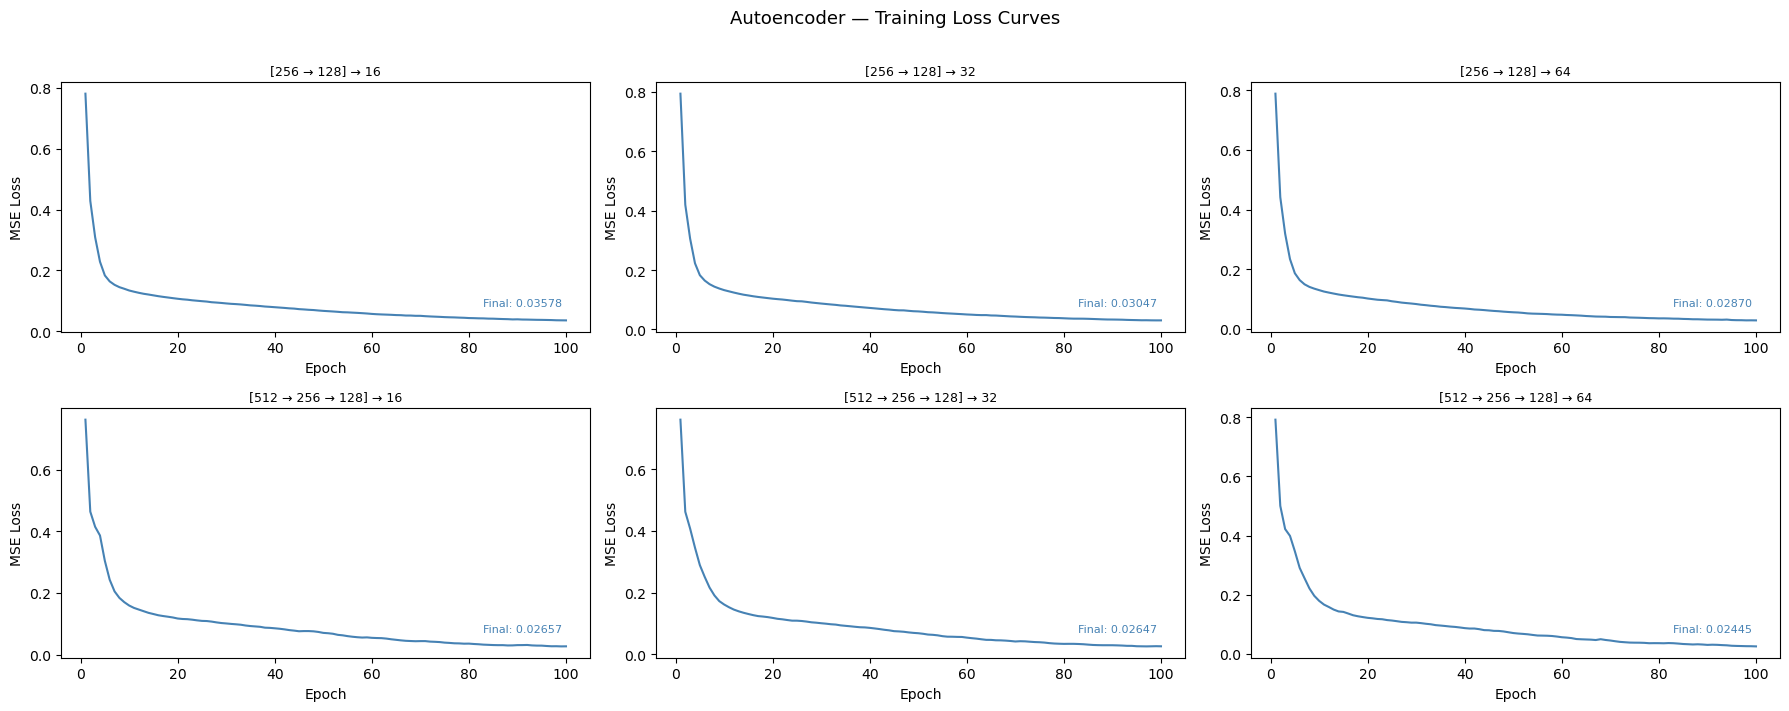

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 7))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]
    ax.plot(range(1, EPOCHS + 1), r['train_losses'], color='steelblue', lw=1.5)
    ax.set_title(r['label'], fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    final_loss = r['train_losses'][-1]
    ax.annotate(f'Final: {final_loss:.5f}', xy=(EPOCHS, final_loss),
                xytext=(-60, 10), textcoords='offset points', fontsize=8, color='steelblue')

plt.suptitle('Autoencoder — Training Loss Curves', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/autoencoder_training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

All 6 configurations follow the same overall shape: loss starts high (~0.75–0.80) and drops sharply in the first 10 epochs as the model quickly learns the gross structure of normal spectra, then continues to decrease more gradually before flattening out by epoch ~80–100.

**Shallow row [256 → 128] (top):**
- Final losses decrease as the latent dimension grows: 0.03578 (latent=16) → 0.03047 (latent=32) → 0.02870 (latent=64). A larger bottleneck gives the encoder more capacity to preserve information, so reconstruction is easier and loss is lower.
- All three shallow curves appear largely flattened by epoch 100, indicating stable convergence.

**Deep row [512 → 256 → 128] (bottom):**
- Final losses are consistently lower than the shallow configs at every latent dim: 0.02657 (latent=16) → 0.02647 (latent=32) → 0.02445 (latent=64). The additional hidden layer gives the encoder more expressive power to model the normal spectra manifold.
- The deep curves still show a slight downward slope near epoch 100, suggesting they have not fully converged and could benefit from more epochs.

**Key Takeaway:** Architecture depth has a larger effect on final loss than latent dimension. Deep configs reach lower training loss at every bottleneck size, confirming they learn a richer representation of normal spectra.

## 7. Anomaly Score Distributions

One histogram per configuration. Blue bars are normal samples, orange are ambient (anomaly) samples, and the red dashed line is the decision threshold.

**What to look for:** configurations where the orange and blue distributions are most separated indicate a better-performing model. A model that reconstructs anomalies poorly will push orange scores to the right, away from the blue distribution.

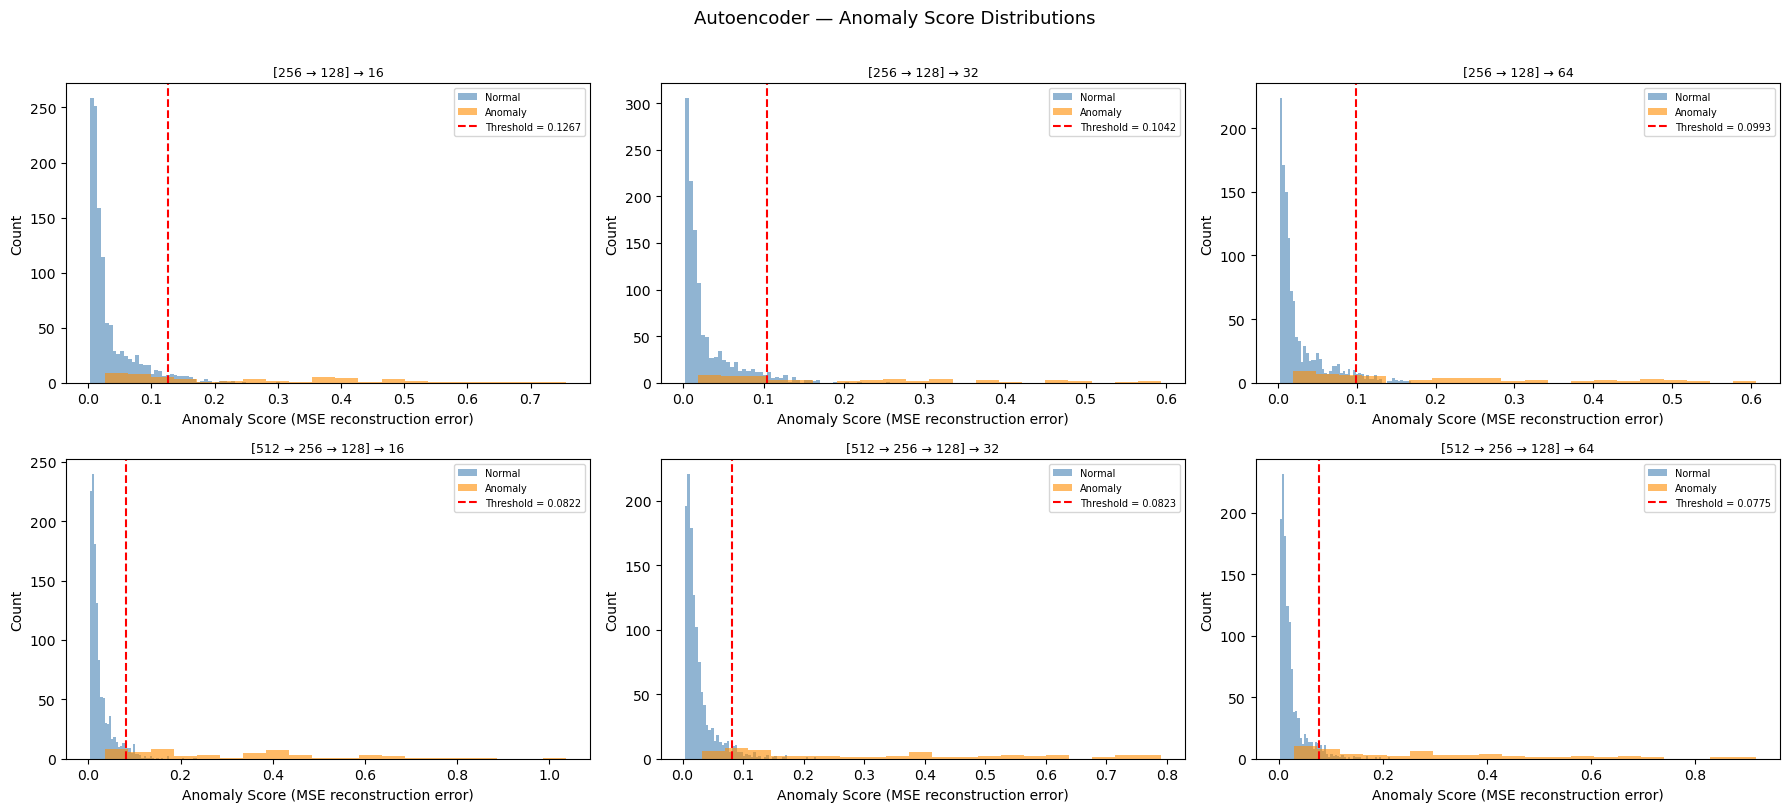

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]

    ax.hist(r['scores_normal'],  bins=50, alpha=0.6, color='steelblue',  label='Normal')
    ax.hist(r['scores_anomaly'], bins=20, alpha=0.6, color='darkorange', label='Anomaly')
    ax.axvline(r['threshold'], color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold = {r["threshold"]:.4f}')

    ax.set_title(r['label'], fontsize=9)
    ax.set_xlabel('Anomaly Score (MSE reconstruction error)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Autoencoder — Anomaly Score Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/autoencoder_anomaly_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

Across all 6 configurations, normal scores (blue) cluster tightly near zero while anomaly scores (orange) spread broadly to the right — confirming the autoencoder reconstructs normal spectra well but struggles with ambient ones. However, the degree of separation varies significantly between shallow and deep architectures.

**Shallow row [256 → 128] (top):**
- Normal scores peak sharply near 0 and have a moderate tail. Thresholds are relatively high: 0.1267 (latent=16), 0.1042 (latent=32), 0.0993 (latent=64).
- As latent dim increases, the threshold shifts left because the model reconstructs normal samples more accurately, compressing the normal score distribution.
- Anomaly scores spread to roughly 0.6–0.75, with a moderate number falling above the threshold. The two distributions overlap noticeably in the 0–0.1 range.

**Deep row [512 → 256 → 128] (bottom):**
- Normal scores are more tightly packed near 0 (due to better reconstruction), pushing the thresholds lower: 0.0822 (latent=16), 0.0823 (latent=32), 0.0775 (latent=64).
- Anomaly scores spread much further right than in the shallow configs, reaching up to ~1.05 for latent=16. This wider spread means substantially more orange bars fall above the lower threshold.
- The visual separation between the two distributions is markedly cleaner in the deep configs — the anomaly tail is long and distinct from the tight normal cluster.

**Key Takeaway:** Deep configs produce better-separated distributions in both directions: normal scores become more concentrated near zero (lower thresholds) while anomaly scores push further out (longer tails). This combined effect is what drives the large jump in TP seen in the confusion matrices.

## 8. Confusion Matrices

One confusion matrix per configuration, labeled with TN, FP, FN, TP.

**What to look for:** high TP (anomalies correctly caught) and low FN (anomalies missed). FN is the most costly error in anomaly detection.

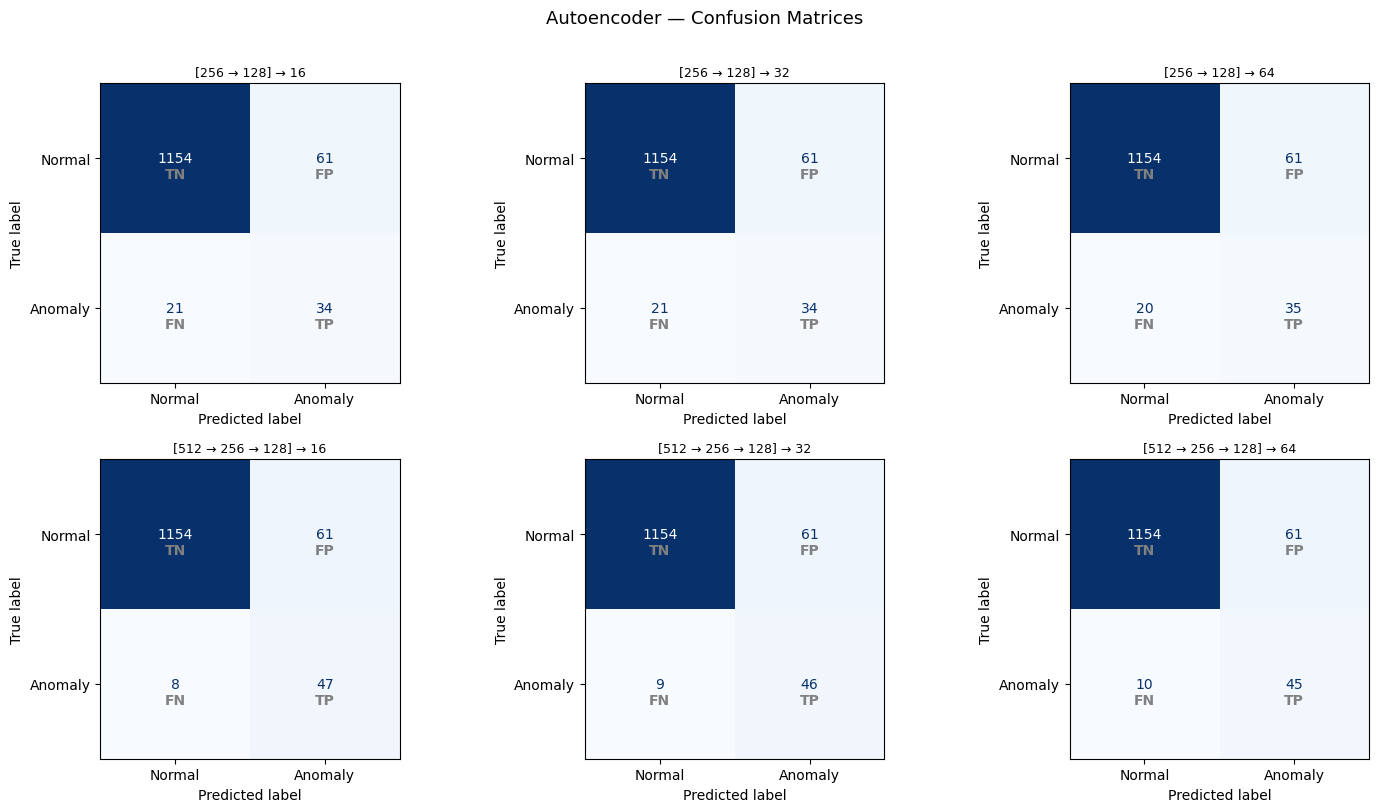

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cell_labels = [['TN', 'FP'], ['FN', 'TP']]

for i, r in enumerate(results):
    ax = axes[i]

    disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'], display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    for row in range(2):
        for col in range(2):
            ax.text(col, row, f'\n\n{cell_labels[row][col]}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='gray')

    ax.set_title(r['label'], fontsize=9)

plt.suptitle('Autoencoder — Confusion Matrices', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/autoencoder_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

| Configuration | TN | FP | FN | TP | Recall |
|---|---|---|---|---|---|
| [256 → 128] → 16 | 1154 | 61 | 21 | 34 | 0.62 |
| [256 → 128] → 32 | 1154 | 61 | 21 | 34 | 0.62 |
| [256 → 128] → 64 | 1154 | 61 | 20 | 35 | 0.64 |
| [512 → 256 → 128] → 16 | 1154 | 61 | 8 | **47** | **0.85** |
| [512 → 256 → 128] → 32 | 1154 | 61 | 9 | 46 | 0.84 |
| [512 → 256 → 128] → 64 | 1154 | 61 | 10 | 45 | 0.82 |

**What stays constant:** All 6 configurations share TN=1154 and FP=61. This is expected — the threshold is set at the 95th percentile of normal training scores, so by construction exactly 5% of normal samples (~61 out of 1215) will always fall above it regardless of architecture.

**Shallow row [256 → 128]:** TP stays nearly flat at 34–35 across all latent dims, meaning the latent dimension has negligible effect on anomaly detection for shallow architectures. The model catches only 62–64% of the ambient samples.

**Deep row [512 → 256 → 128]:** A dramatic improvement over the shallow row. TP jumps to 45–47, catching 82–85% of anomalies. FN drops from 20–21 down to just 8–10 — the model misses very few ambient samples. Within the deep group, smaller latent dim performs marginally better (latent=16 gives TP=47 vs latent=64 giving TP=45).

**Key Takeaway:** Architecture depth is the dominant factor. Switching from shallow to deep nearly doubles the number of anomalies caught (34 → 47 TP) while keeping false positives identical. The best configuration overall is [512 → 256 → 128] → 16 with TP=47 and FN=8 (85.5% recall).

## 9. ROC Curves

All 6 ROC curves plotted together on one chart. A curve closer to the top-left corner means better performance. The gray dashed diagonal is the random baseline (AUC = 0.5).

**What to look for:** the configuration with the highest AUC has the best threshold-independent ability to separate normal from anomalous samples.

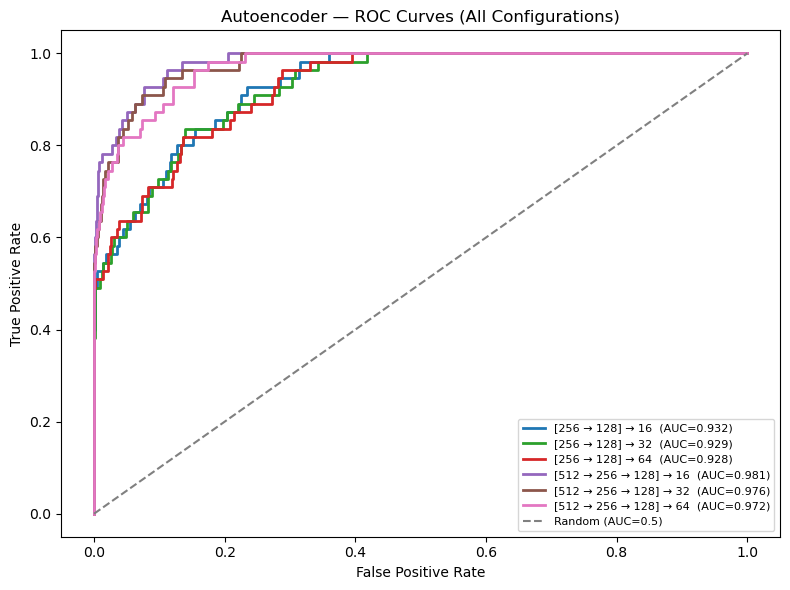

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, r in enumerate(results):
    ax.plot(r['fpr'], r['tpr'], lw=2, color=colors[i],
            label=f"{r['label']}  (AUC={r['roc_auc']:.3f})")

# Random baseline
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC=0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Autoencoder — ROC Curves (All Configurations)')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('../figures/autoencoder_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

The ROC curves form two clear, well-separated clusters that mirror the confusion matrix findings.

**Deep configs [512 → 256 → 128] (purple, brown, pink — top cluster):**
- All three curves hug the top-left corner tightly, reaching TPR ~0.65 at FPR=0.05 and TPR ~0.85 before FPR=0.10.
- AUC rankings: latent=16 (0.981) > latent=32 (0.976) > latent=64 (0.972). All three are closely bunched — the latent dimension produces only small differences at this depth.

**Shallow configs [256 → 128] (blue, green, red — lower cluster):**
- All three curves are tightly grouped together, reflecting the nearly identical TP counts (34–35) seen in the confusion matrices.
- AUC rankings: latent=16 (0.932) > latent=32 (0.929) > latent=64 (0.928). The spread is minimal (~0.004 across all three).

**Depth gap:** The jump in AUC from shallow to deep (~0.04–0.05) is far larger than any effect of latent dimension within either group. Depth is clearly the dominant architectural choice for this task.

**Key Takeaway:** [512 → 256 → 128] → 16 achieves the best AUC of 0.981, a substantial improvement over the best shallow config (0.932) and the best KNN configuration tested previously (0.922). All autoencoder configurations comfortably outperform Isolation Forest (AUC=0.684).

## 10. Summary Table

A single table summarising all key metrics across every configuration. Sorted by ROC-AUC (descending) so the best-performing setup appears first.

- **AUC** — threshold-independent ranking ability (higher is better)
- **TP** — anomalies correctly caught (higher is better)
- **FN** — anomalies missed (lower is better)
- **FP** — normal samples falsely flagged (lower is better)
- **Recall** — TP / (TP + FN), fraction of anomalies detected
- **Precision** — TP / (TP + FP), fraction of flagged samples that are real anomalies

In [11]:
# Build summary DataFrame
summary = pd.DataFrame([{
    'Configuration': r['label'],
    'Hidden Dims':   str(r['hidden_dims']),
    'Latent Dim':    r['latent_dim'],
    'Threshold':     round(r['threshold'], 6),
    'AUC':           round(r['roc_auc'], 3),
    'TP':            int(r['tp']),
    'FN':            int(r['fn']),
    'FP':            int(r['fp']),
    'TN':            int(r['tn']),
    'Recall':        round(r['recall'], 3),
    'Precision':     round(r['precision'], 3),
} for r in results])

# Sort by AUC descending
summary = summary.sort_values('AUC', ascending=False).reset_index(drop=True)

display(summary)

,Configuration,Hidden Dims,Latent Dim,Threshold,AUC,TP,FN,FP,TN,Recall,Precision
0,[512 → 256 → 128] → 16,"[512, 256, 128]",16,0.082155,0.981,47,8,61,1154,0.855,0.435
1,[512 → 256 → 128] → 32,"[512, 256, 128]",32,0.082297,0.976,46,9,61,1154,0.836,0.430
2,[512 → 256 → 128] → 64,"[512, 256, 128]",64,0.077469,0.972,45,10,61,1154,0.818,0.425
3,[256 → 128] → 16,"[256, 128]",16,0.126691,0.932,34,21,61,1154,0.618,0.358
4,[256 → 128] → 32,"[256, 128]",32,0.104157,0.929,34,21,61,1154,0.618,0.358
5,[256 → 128] → 64,"[256, 128]",64,0.099254,0.928,35,20,61,1154,0.636,0.365


## 11. Final Summary

**[512 → 256 → 128] → 16 is the best configuration.** Here's the full breakdown:

---

**Effect of Architecture Depth**

Depth is the single most impactful factor across every metric:

| Metric | Best shallow ([256→128]→16) | Best deep ([512→256→128]→16) | Improvement |
|--------|---|---|---|
| AUC | 0.932 | **0.981** | +0.049 |
| TP | 34 | **47** | +13 |
| FN | 21 | **8** | −13 |
| Recall | 0.618 | **0.855** | +0.237 |

Adding a third hidden layer (512) allows the encoder to learn a substantially richer representation of the normal spectral manifold. This results in tighter normal score distributions and larger reconstruction errors for anomalies — both of which directly improve separation.

---

**Effect of Latent Dimension**

Within each architecture group, latent dimension has only a minor effect:
- **Shallow:** TP varies by just 1 (34 → 35) across latent=16 to 64. AUC drops by 0.004.
- **Deep:** TP drops by 2 (47 → 45) from latent=16 to 64. AUC drops by 0.009.

The trend is consistent: smaller latent dim performs marginally better for anomaly detection, because more aggressive compression forces the model to learn only the most common normal patterns, making it less likely to inadvertently reconstruct anomalies. However, the effect is small compared to depth.

---

**Comparison to Other Models**

| Model | Best AUC | Best Recall |
|-------|----------|-------------|
| Isolation Forest | 0.684 | 0.04 |
| KNN (K=3, euclidean) | 0.922 | 0.455 |
| Autoencoder [256→128]→16 | 0.932 | 0.618 |
| **Autoencoder [512→256→128]→16** | **0.981** | **0.855** |

The deep autoencoder is the strongest model tested so far. Its non-linear learned representation of the normal spectral manifold gives it a decisive advantage over distance-based (KNN) and tree-based (Isolation Forest) methods.

---

**Recommended Next Steps**
- Train the best config ([512→256→128]→16) for more epochs (e.g. 200) — the loss curve was still slightly declining at epoch 100
- Explore even deeper architectures or a smaller latent dim (e.g. 8) to further increase reconstruction difficulty for anomalies